In [31]:
import numpy as np
import torch
import trimesh
import open3d as o3d
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

import implicit_reps as ir

In [32]:
source_filepath = 'data/surfaces/wobbly-torus-compare/wobbly_torus200.ply'# id of the analytic implicit function (see implicit_reps.py for the full

target_sdf_id = 'wobbly_torus'#sdf/implicit id



source_filepath = 'data/surfaces/twisted-torus-compare/twisted_torus.ply'
target_sdf_id = 'twisted_torus'#sdf/implicit id

source_filepath = 'data/surfaces/urchin-compare/urchin.ply'
target_sdf_id = 'urchin'#sdf/implicit id

source_mesh = trimesh.load( source_filepath, process=False)





In [33]:
# Centroid of every source triangle
source_centroids = source_mesh.triangles_center.astype(np.float32)  # (F_src, 3)



def implicit_normals(points, sdf_id):
    """Unit surface normals from the gradient of an implicit function's
    SDF, evaluated at `points` (N, 3). For a true SDF the gradient at any
    point is a unit vector pointing away from the nearest surface point
    (the Eikonal property |grad(sdf)| = 1), so no closest-point search
    against a discretized target mesh is needed."""
    pts = torch.from_numpy(points).float().unsqueeze(0)  # (1, N, 3)
    pts.requires_grad_(True)
    sdf_vals = ir.sdf(pts, target_sdf_id)
    grad, = torch.autograd.grad(sdf_vals.sum(), pts)
    grad = grad[0]  # (N, 3)
    normals = grad / grad.norm(dim=-1, keepdim=True)
    return normals.detach().numpy()

source_normals = source_mesh.face_normals               # (F_src, 3)
target_normals = implicit_normals(source_centroids, target_sdf_id)  # (F_src, 3)

dots = np.einsum('ij,ij->i', source_normals, target_normals)

flipped_mask = dots < 0
n_flipped = np.sum(flipped_mask)
print(f"{n_flipped} / {len(dots)} source faces ({100 * n_flipped / len(dots):.2f}%) "
      f"have a flipped normal relative to the implicit target normal")

# Same proportion but weighted by triangle area, so a handful of large
# flipped triangles counts for more than many tiny ones (and vice versa).
face_areas = source_mesh.area_faces
area_weighted_flipped = np.sum(face_areas[flipped_mask]) / np.sum(face_areas)
print(f"{100 * area_weighted_flipped:.2f}% of source surface area "
      f"has a flipped normal relative to the implicit target normal")

0 / 215040 source faces (0.00%) have a flipped normal relative to the implicit target normal
0.00% of source surface area has a flipped normal relative to the implicit target normal


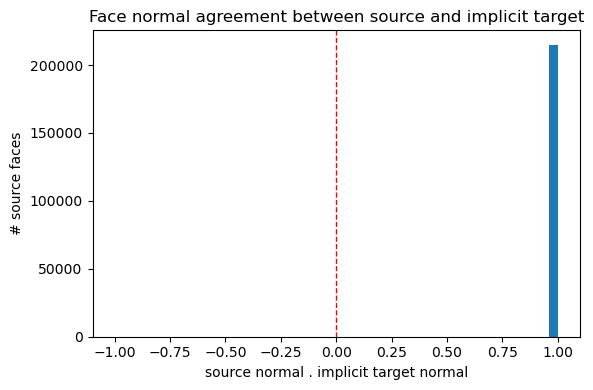

In [34]:
# Histogram of the normal-dot-products
plt.figure(figsize=(6, 4))
plt.hist(dots, bins=50, range=(-1, 1))
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('source normal . implicit target normal')
plt.ylabel('# source faces')
plt.title('Face normal agreement between source and implicit target')
plt.tight_layout()
plt.show()

In [35]:
# Interactive open3d view of the source mesh, faces colored by the dot
# product against the implicit target normal (blue = normals agree, red
# = flipped). Opens a window you can freely orbit.
cmap = plt.get_cmap('coolwarm')
face_colors = cmap((np.clip(dots, -1, 1) + 1) / 2)[:, :3]  # (F_src, 3)

# Give every triangle its own 3 vertices (no sharing) so that per-vertex
# coloring + per-vertex normals render as a flat, per-face color/shading
# instead of being smoothed across the surface.
verts_flat = source_mesh.vertices[source_mesh.faces].reshape(-1, 3)
faces_flat = np.arange(len(verts_flat)).reshape(-1, 3)
vertex_colors = np.repeat(face_colors, 3, axis=0)

source_o3d = o3d.geometry.TriangleMesh(
    o3d.utility.Vector3dVector(verts_flat),
    o3d.utility.Vector3iVector(faces_flat),
)
source_o3d.vertex_colors = o3d.utility.Vector3dVector(vertex_colors)
source_o3d.compute_vertex_normals()

o3d.visualization.draw_geometries(
    [source_o3d], mesh_show_back_face=True
)